# Динамика курса рубля к USD, EUR и CNY (2022–2026): волатильность и корреляции

**Источник данных:** официальный XML-API Банка России (cbr.ru)

**Вопросы исследования:**
1. Как менялись курсы USD, EUR, CNY к рублю за последние годы?
2. В какие периоды была наибольшая волатильность (резкие скачки курса)?
3. Насколько синхронно двигаются разные валюты. Можно ли говорить об общем рублёвом тренде или каждая валюта живёт своей жизнью?
4. Как выглядит переход торговых расчётов с доллара на юань в динамике курса CNY?


## 1. Загрузка данных с API ЦБ РФ

Используем метод `XML_dynamic.asp` — он позволяet получить курс валюты за весь период одним запросом (в отличие от `XML_daily.asp`, который отдаёт курс только на одну дату).

Коды валют ЦБ (`VAL_NM_RQ`): USD — `R01235`, EUR — `R01239`, CNY (юань) — `R01375`.

In [10]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CURRENCIES = {
    "USD": "R01235",
    "EUR": "R01239",
    "CNY": "R01375",
}

DATE_FROM = "01/01/2022"
DATE_TO = "18/09/2026"

def fetch_currency(code, date_from, date_to):
    url = "https://www.cbr.ru/scripts/XML_dynamic.asp"
    params = {"date_req1": date_from, "date_req2": date_to, "VAL_NM_RQ": code}
    resp = requests.get(url, params=params, timeout=30)
    resp.encoding = "windows-1251"  # ЦБ отдаёт XML в этой кодировке
    root = ET.fromstring(resp.content)

    records = []
    for record in root.findall("Record"):
        date = record.get("Date")
        nominal = int(record.find("Nominal").text)
        value = float(record.find("Value").text.replace(",", "."))
        records.append({"Date": date, "Value": value / nominal})

    df = pd.DataFrame(records)
    df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y")
    return df.set_index("Date")["Value"]

series = {}
for name, code in CURRENCIES.items():
    print(f"Загружаю {name}...")
    series[name] = fetch_currency(code, DATE_FROM, DATE_TO)

rates = pd.DataFrame(series).sort_index()
print("Загружено записей:", rates.shape)
rates.head()

Загружаю USD...
Загружаю EUR...
Загружаю CNY...
Загружено записей: (1163, 3)


,USD,EUR,CNY
Date,,,
2022-01-11,75.1315,85.1315,11.7907
2022-01-12,74.8355,84.8784,11.7446
2022-01-13,74.5277,84.6709,11.7088
2022-01-14,74.5686,85.4556,11.7246
2022-01-15,75.7668,86.8894,11.9457


## 2. Динамика курсов во времени

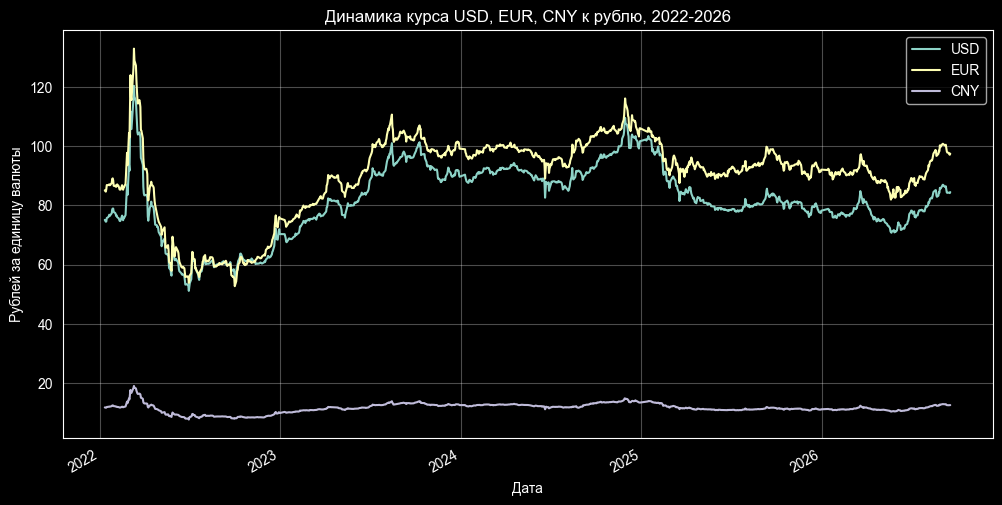

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
rates.plot(ax=ax)
ax.set_title("Динамика курса USD, EUR, CNY к рублю, 2022-2026")
ax.set_xlabel("Дата")
ax.set_ylabel("Рублей за единицу валюты")
ax.grid(alpha=0.3)
plt.show()

**Вывод:** впишите после запуска — например, в какие периоды виден резкий скачок всех трёх валют одновременно (значит, ослабление именно рубля), а где валюты расходятся (значит, дело в конкретной валюте, а не в рубле в целом).

## 3. Волатильность: где курс скакал сильнее всего

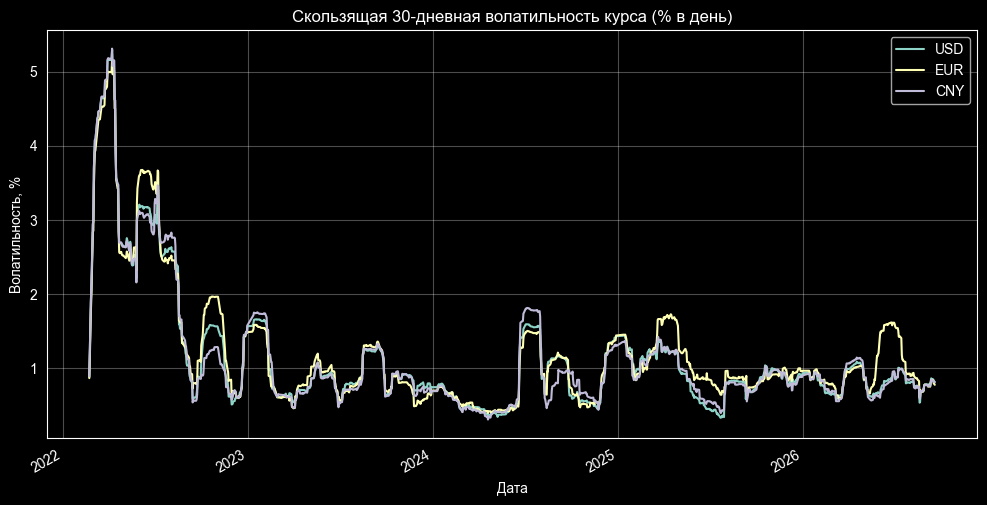

Среднегодовая волатильность по валютам:
       USD   EUR   CNY
Date                  
2022  2.56  2.62  2.56
2023  0.86  0.86  0.86
2024  0.92  0.91  0.93
2025  0.90  1.03  0.90
2026  0.82  1.01  0.83


In [12]:
daily_returns = rates.pct_change().dropna()

# скользящая 30-дневная волатильность (стандартное отклонение дневных изменений)
rolling_vol = daily_returns.rolling(30).std() * 100  # в процентах

fig, ax = plt.subplots(figsize=(12, 6))
rolling_vol.plot(ax=ax)
ax.set_title("Скользящая 30-дневная волатильность курса (% в день)")
ax.set_xlabel("Дата")
ax.set_ylabel("Волатильность, %")
ax.grid(alpha=0.3)
plt.show()

print("Среднегодовая волатильность по валютам:")
print(daily_returns.groupby(daily_returns.index.year).std().round(4) * 100)

**Вывод:** в 2022 году волатильность всех трёх валют была примерно в 3 раза выше, чем в остальные годы (2.5–2.6% против 0.8–1%). Это логично, ведь тогда был самый нестабильный период для рубля. Начиная с 2023 года ситуация заметно стала стабильнее и держится примерно на одном уровне.


In [13]:
# топ 5 самых резких дневных скачков по каждой валюте
for cur in rates.columns:
    print(f"\nТоп-5 самых сильных дневных скачков курса {cur}:")
    top_moves = daily_returns[cur].abs().sort_values(ascending=False).head(5)
    for date, _ in top_moves.items():
        change_pct = daily_returns.loc[date, cur] * 100
        print(f"  {date.date()}: {change_pct:+.2f}%")


Топ-5 самых сильных дневных скачков курса USD:
  2022-03-03: +12.54%
  2022-03-01: +11.98%
  2022-05-27: +10.21%
  2022-03-10: +9.71%
  2022-03-04: +8.24%

Топ-5 самых сильных дневных скачков курса EUR:
  2022-03-01: +11.62%
  2022-03-03: +11.31%
  2022-05-27: +11.25%
  2022-03-10: +9.36%
  2022-03-04: +8.26%

Топ-5 самых сильных дневных скачков курса CNY:
  2022-03-03: +12.56%
  2022-03-01: +12.03%
  2022-05-27: +10.32%
  2022-03-10: +9.73%
  2022-02-25: +8.32%


**Вывод:** заметно, что 4 из 5 самых резких скачков совпадают по датам сразу у USD, EUR и CNY  1, 3, 10 марта и 27 мая 2022. То есть валюты скакнули не по отдельности, а все вместе в одни и те же дни. Это подтверждает вывод из раздела про корреляции: скачки, скорее всего, вызваны не событиями вокруг конкретной валюты, а общим шоком для рубля целиком, это как раз период сразу после 24 февраля 2022, когда ЦБ резко поднял ключевую ставку и ограничил торги на бирже.

## 4. Насколько валюты движутся синхронно

Корреляция дневных изменений курсов:
      USD   EUR   CNY
USD  1.00  0.91  0.93
EUR  0.91  1.00  0.88
CNY  0.93  0.88  1.00


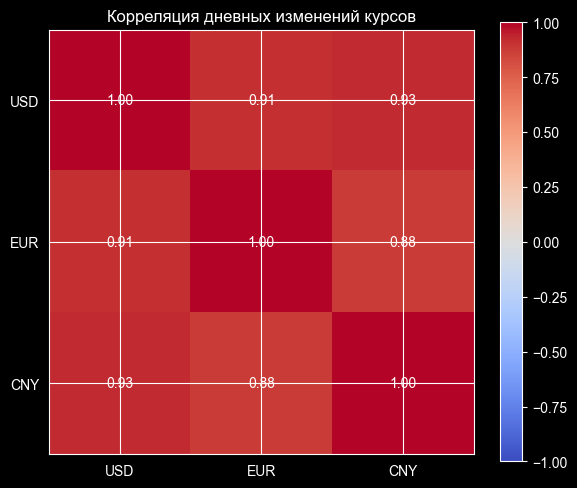

In [14]:
corr = daily_returns.corr()
print("Корреляция дневных изменений курсов:")
print(corr.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Корреляция дневных изменений курсов")
plt.colorbar(im)
plt.tight_layout()
plt.show()

**Вывод:** курсы USD, EUR и CNY к рублю движутся почти синхронно (корреляция 0.88–0.93) — это говорит о том, что на дневные колебания сильнее влияет общий фактор силы и слабости рубля, а не индивидуальная динамика конкретной валюты

## 5. Юань: как менялась его роль

In [15]:
# доля дней, когда CNY торговался стабильнее (меньшая волатильность), чем USD, по годам
comparison = pd.DataFrame({
    "USD_volatility": daily_returns["USD"].groupby(daily_returns.index.year).std(),
    "CNY_volatility": daily_returns["CNY"].groupby(daily_returns.index.year).std(),
})
comparison["CNY_more_stable"] = comparison["CNY_volatility"] < comparison["USD_volatility"]
print(comparison.round(4))

      USD_volatility  CNY_volatility  CNY_more_stable
Date                                                 
2022          0.0256          0.0256            False
2023          0.0086          0.0086            False
2024          0.0092          0.0093            False
2025          0.0090          0.0090            False
2026          0.0082          0.0083            False


**Вывод:** волатильность юаня не оказалась ниже волатильности доллара ни в один год, обе валюты колеблются почти идентично (расхождение только в сотых долях). Причина в том, что с 2022 года официальный курс ЦБ по всем валютам стал рассчитываться по внебиржевым данным из-за ограничений биржевых торгов доллара и евро, что могло унифицировать методику расчёта волатильности для всех трёх валют.

## Итоговые выводы

- Самая высокая волатильность всех трёх валют пришлась на 2022 год (2.56–2.62% в день) это примерно в 3 раза выше, чем в 2023–2026 годах (0.8–1%). Логично: 2022 был самым нестабильным годом для рубля.
- USD и EUR коррелируют на уровне 0.91, а USD и CNY даже чуть сильнее, на уровне 0.93. Это немного удивило: ожидала, что юань будет двигаться более независимо, раз стал основной торговой валютой после ухода доллара и евро. Получается, что все три курса скорее зависят от общей силы/слабости рубля, чем от специфики конкретной валюты.
- Юань не стал более стабильным индикатором по сравнению с долларом — волатильность у них почти одинаковая во все годы (например, в 2025: 0.90% у обоих).
- Самый резкий разовый скачок курса USD произошёл 2022-03-03 (+12.54%), попадает в период сразу после 24 февраля 2022, когда ЦБ резко поднял ключевую ставку и ввёл ограничения на биржевые торги. Ещё один заметный скачок 27 мая 2022 (+10.21%) по новостям это совпадает с периодом, когда власти немного ослабили требования по обязательной продаже валютной выручки экспортёрами, из-за чего рубль после сильного укрепления в мае немного пошел обратно вверх по курсу доллара.
- Ограничение анализа: данные только официальный курс ЦБ, а также ЦБ с определённого периода мог сглаживать курс, это не отражает точную рыночную волатильность внутри дня.